
## k-Means Clustering Workflow for Facies-Like Grouping from Well Logs

#### Anika Gupta
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### [LinkedIn](https://www.linkedin.com/in/anikagupta)

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Graduate Student, The University of Texas at Austin



### Executive Summary

This project investigates whether k-Means clustering can be used to generate meaningful facies-like groupings from well-log data when labeled facies are unavailable, addressing the gap in subsurface interpretation workflows that rely heavily on core or expert labeling. To answer this question, public SEG well-log data were cleaned, standardized, and clustered for k = 2–10, with model quality assessed using the Elbow Method, Silhouette Score, Davies–Bouldin Index, and visual evaluation in feature space and with depth. Although clustering metrics peaked at k = 4, the final model selected k = 3 for its clearer geological interpretability, producing shale-like, transitional, and sand-like groups that align with expected petrophysical trends and stratigraphic layering. Based on these findings, k-Means is recommended as an effective semi-supervised tool for initial facies generation, interpretation support, and quality control in data-driven subsurface modeling.

### Import Packages

```python

```



In [134]:
import numpy as np                                                      # for working with data and model arrays
import pandas as pd                                                     # loading and cleaning well-log datasets
import matplotlib.pyplot as plt                                         # plotting histograms, cross-plots, and cluster visualizations
from sklearn.preprocessing import StandardScaler                        # Z-score scaling for k-Means distance consistency
from sklearn.cluster import KMeans                                      # k-Means clustering algorithm
from sklearn.metrics import (silhouette_score, davies_bouldin_score, adjusted_rand_score, classification_report, confusion_matrix)     # cluster evaluation metrics
from sklearn.decomposition import PCA                                   # dimensionality reduction for visualization
from sklearn.linear_model import LogisticRegression                     # supervised baseline using facies labels
from sklearn.model_selection import train_test_split                   # split data into train / test sets
# Plot style tweaks for cleaner figures
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True

### Functions

The following functions will be used in the workflow.
The following functions are from Professor Michael Pyrcz (@GeostatsGuy), Subsurface Machine Learning course notebooks from [GeostatsGuy GitHub](https://github.com/GeostatsGuy).
```python

```


In [135]:
def compute_kmeans_metrics(X_scaled, k_values): #Compute Silhouette, DBI, and Inertia for each k.                                          
    results = []
    for k in k_values:
        km = KMeans(n_clusters=k, n_init=10, random_state=73073)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        dbi = davies_bouldin_score(X_scaled, labels)
        inertia = km.inertia_
        results.append([k, sil, dbi, inertia])
    return results


def plot_metric(k_values, metric, ylabel, title): #Generic plot helper for hyperparameter tuning curves.
    plt.plot(k_values, metric, marker="o")
    plt.xlabel("k")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


### Load Data

For this workflow, we use the well-log dataset from the **2016 SEG Machine Learning Contest**, which is publicly available and can be accessed directly from the cloud at:  
<https://raw.githubusercontent.com/seg/2016-ml-contest/master/training_data.csv>  

The following features are used for clustering:
- **Depth** – ft  
- **GR** – Gamma Ray (API)
- **ILD_log10** – log₁₀ deep resistivity (log₁₀[ohm·m])
- **DeltaPHI** – neutron-density porosity separation
- **PHIND** – porosity indicator
- **PE** – photoelectric factor (barns/e–)
- **Facies** – discrete lithofacies label (for evaluation only)



In [136]:
url = "https://raw.githubusercontent.com/seg/2016-ml-contest/master/training_data.csv"
my_data = pd.read_csv(url) # load the comma delimited data file from GitHub repository
my_data = my_data[["Depth", "GR", "ILD_log10", "DeltaPHI", "PHIND", "PE", "Facies"]] # Keep only the features needed for this workflow                    
my_data = my_data.replace(-999.25, np.nan).dropna().reset_index(drop=True) # Clean invalid values and remove incomplete rows
my_data.head()


,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,Facies
0,2793.0,77.45,0.664,9.9,11.915,4.6,3
1,2793.5,78.26,0.661,14.2,12.565,4.1,3
2,2794.0,79.05,0.658,14.8,13.050,3.6,3
3,2794.5,86.10,0.655,13.9,13.115,3.5,3
4,2795.0,74.58,0.647,13.5,13.300,3.4,3


### k-Means Clustering Workflow for Facies-Like Grouping from Well Logs

This workflow applies k-Means clustering to standardized well-log features to explore whether facies-like groupings can be recovered without labels. The main steps are: scale features, sweep k-values, evaluate cluster quality, then apply and visualize the final clustering.


### 1. Scale Features for Clustering

Standardize the selected log features so they contribute equally to the k-Means distance metric.


In [137]:
# Select the continuous features used in k-Means clustering
feature_cols = ["GR", "ILD_log10", "DeltaPHI", "PHIND", "PE"]
X = my_data[feature_cols].values

# Standardize features to zero mean and unit variance
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

Xs[:5]


array([[ 0.36674916,  0.08800759,  1.21273704, -0.20372255,  0.9765322 ],
       [ 0.39300519,  0.07560101,  2.03520936, -0.11928272,  0.41850492],
       [ 0.41861293,  0.06319443,  2.14997295, -0.05627761, -0.13952236],
       [ 0.64713766,  0.05078785,  1.97782757, -0.04783363, -0.25112781],
       [ 0.27371852,  0.01770362,  1.90131852, -0.02380075, -0.36273327]])

### 2. Sweep k and Compute Cluster Metrics

Evaluate k-Means for a range of k-values (2–10) and compute Silhouette, DBI, and Inertia to guide model selection.


In [138]:
# Define k range
k_values = range(2, 11)

# Use previously defined helper to compute metrics
results = compute_kmeans_metrics(Xs, k_values)

# Store in DataFrame
metrics_df = pd.DataFrame(results, columns=["k", "Silhouette", "DBI", "Inertia"])
metrics_df



,k,Silhouette,DBI,Inertia
0,2,0.298097,1.298973,11419.529022
1,3,0.328219,1.114201,8872.285237
2,4,0.346535,1.004694,7647.324218
3,5,0.335364,1.061909,6650.449358
4,6,0.260338,1.214446,5910.909106
5,7,0.245821,1.101998,5329.104275
6,8,0.244717,1.153755,4949.675116
7,9,0.249673,1.177363,4651.740235
8,10,0.241131,1.217428,4384.561839


### 3. Visualize Cluster Quality vs k

Plot the tuning metrics versus k to identify the optimal number of clusters.


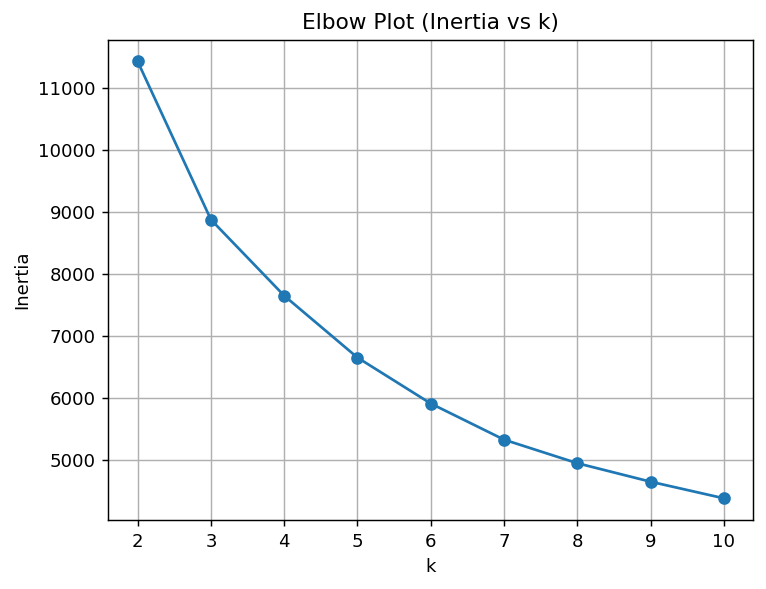

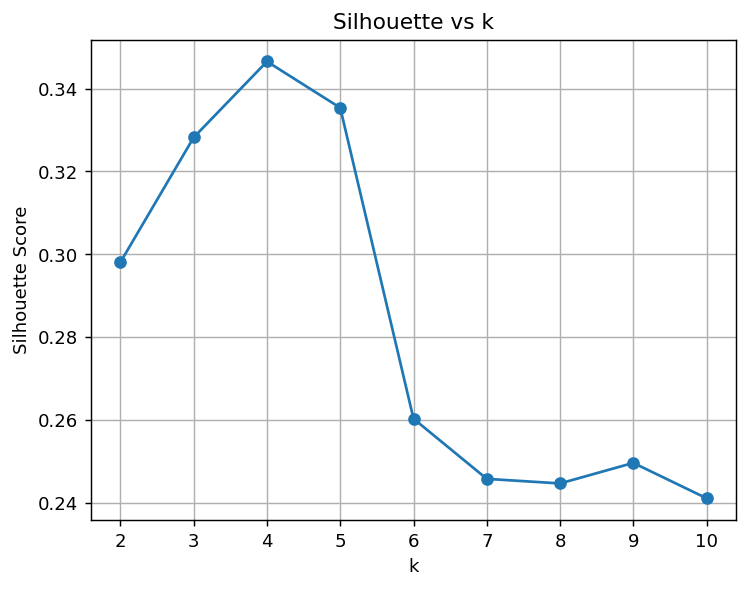

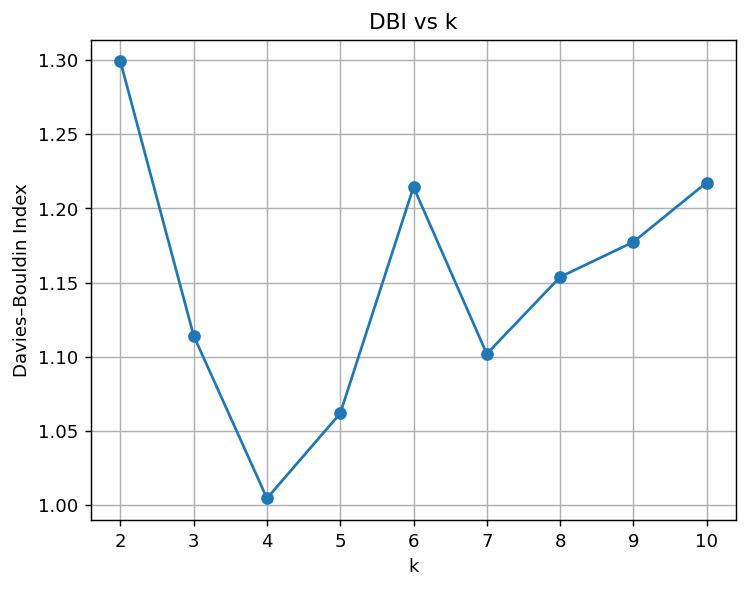

In [139]:
# Elbow plot
plot_metric(metrics_df["k"], metrics_df["Inertia"],
            "Inertia", "Elbow Plot (Inertia vs k)")

# Silhouette plot
plot_metric(metrics_df["k"], metrics_df["Silhouette"],
            "Silhouette Score", "Silhouette vs k")

# Davies–Bouldin plot
plot_metric(metrics_df["k"], metrics_df["DBI"],
            "Davies–Bouldin Index", "DBI vs k")


Although the Silhouette Score and Davies–Bouldin Index reach their optimal values at k = 4, the Elbow plot shows diminishing returns after k ≈ 3. This indicates that both k = 3 and k = 4 are reasonable candidates, with k = 3 offering a simpler and more interpretable geological grouping.


### 4. Final Clustering and Basic Visualizations

Apply k-Means with the chosen k (here, k = 3) and visualize clusters in feature space and along depth.


In [140]:
# Final choice of k based on balance between metrics and interpretability
k_final = 3

# Fit final k-means model
km_final = KMeans(n_clusters=k_final, n_init=10, random_state=73073)
my_data["cluster"] = km_final.fit_predict(Xs)

my_data[["Depth", "GR", "PHIND", "cluster"]].head()


,Depth,GR,PHIND,cluster
0,2793.0,77.45,11.915,0
1,2793.5,78.26,12.565,0
2,2794.0,79.05,13.050,0
3,2794.5,86.10,13.115,0
4,2795.0,74.58,13.300,0


### 5. Cluster Visualizations

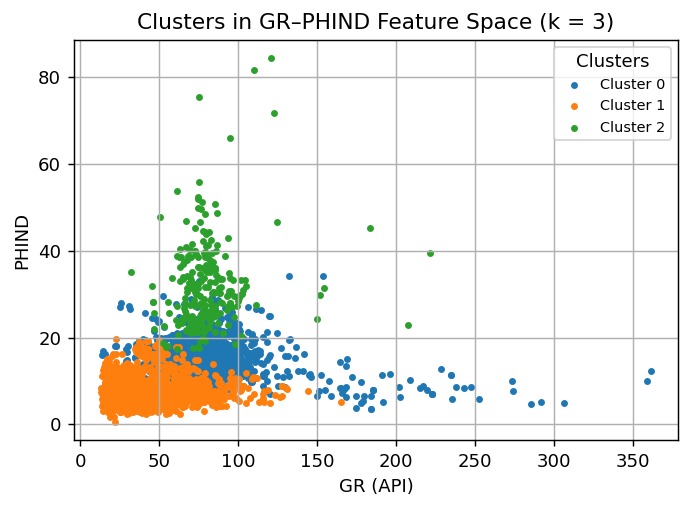

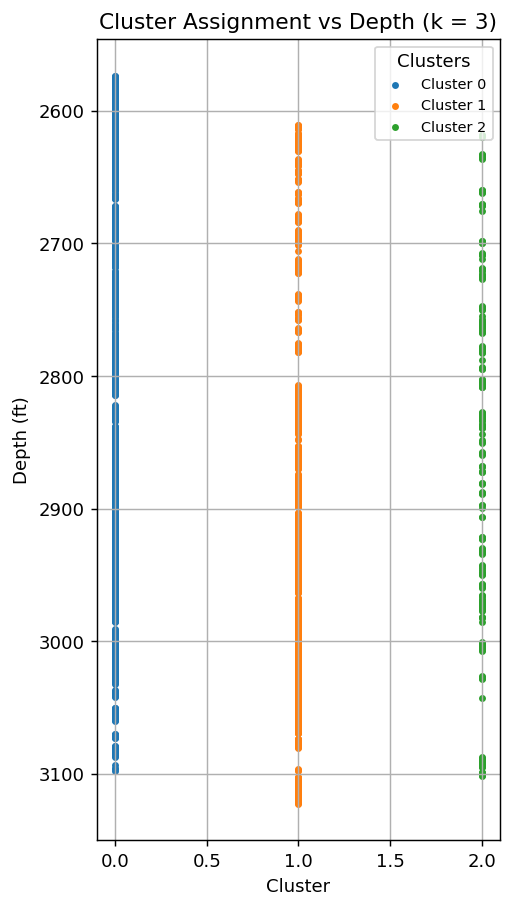

In [141]:
# Scatter plot of GR vs PHIND colored by cluster
plt.figure(figsize=(6,4))

for c in sorted(my_data["cluster"].unique()):
    subset = my_data[my_data["cluster"] == c]
    plt.scatter(subset["GR"], subset["PHIND"], s=8,
                label=f"Cluster {c}")

plt.xlabel("GR (API)")
plt.ylabel("PHIND")
plt.title("Clusters in GR–PHIND Feature Space (k = 3)")
plt.legend(title="Clusters", fontsize=8)
plt.show()

# Cluster assignment as a function of depth
plt.figure(figsize=(4,8))

for c in sorted(my_data["cluster"].unique()):
    subset = my_data[my_data["cluster"] == c]
    plt.scatter(subset["cluster"], subset["Depth"], s=8,
                label=f"Cluster {c}")

plt.gca().invert_yaxis()
plt.xlabel("Cluster")
plt.ylabel("Depth (ft)")
plt.title("Cluster Assignment vs Depth (k = 3)")
plt.legend(title="Clusters", fontsize=8, loc="upper right")
plt.show()


The final clustering uses k = 3 to maintain geological interpretability. These three clusters correspond broadly to shale-rich intervals (high GR, low PHIND), transitional units, and more reservoir-prone sandy units, forming continuous and stratigraphically coherent layers with depth.


### 6. PCA Projection of Clusters


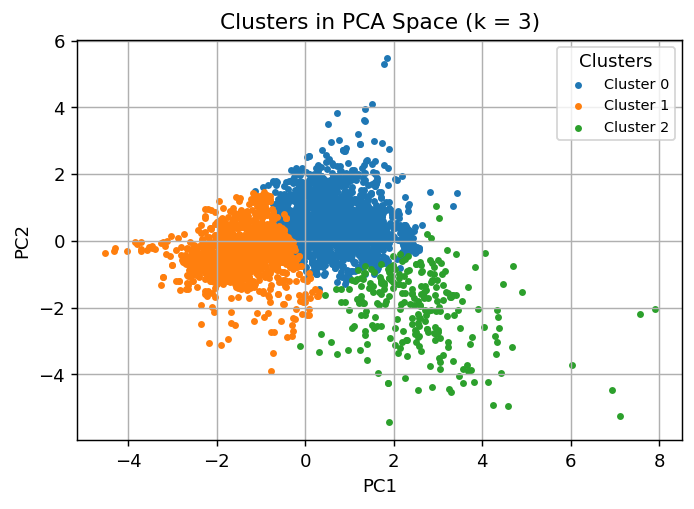

In [142]:
# Apply PCA to reduce the standardized feature space to 2 principal components
plt.figure(figsize=(6,4))

for c in sorted(my_data["cluster"].unique()):
    subset = Xs_pca[my_data["cluster"] == c]
    plt.scatter(subset[:,0], subset[:,1], s=8,
                label=f"Cluster {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA Space (k = 3)") # Plot clusters in PCA space for visual separability
plt.legend(title="Clusters", fontsize=8)
plt.show()



The PCA visualization confirms partial separation among the three clusters, demonstrating that standardized well-log features contain meaningful structure even in reduced dimensionality.


### 7. Logistic Regression Facies Baseline
The following supervised baseline example (Logistic Regression with train–test split) follows the structure of classification workflows demonstrated in Professor Michael Pyrcz’s Subsurface Machine Learning course notebooks from [GeostatsGuy GitHub](https://github.com/GeostatsGuy).

In [143]:
y = my_data["Facies"].values    # Facies labels used for supervised baseline

# Train–test split: 70% training, 30% testing, stratified by facies
X_train, X_test, y_train, y_test = train_test_split(
    Xs, y, test_size=0.3, random_state=73073, stratify=y
)

log_reg = LogisticRegression(max_iter=1000)   # Logistic Regression classifier as a supervised baseline
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)              # Predict facies on the test set

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.62      0.46      0.53        78
           2       0.44      0.63      0.52       222
           3       0.59      0.54      0.56       185
           4       0.35      0.15      0.21        55
           5       0.00      0.00      0.00        65
           6       0.39      0.53      0.45       139
           7       0.00      0.00      0.00        29
           8       0.52      0.62      0.56       149
           9       0.77      0.48      0.59        48

    accuracy                           0.49       970
   macro avg       0.41      0.38      0.38       970
weighted avg       0.45      0.49      0.46       970



The Logistic Regression baseline provides a supervised performance reference and, as expected, achieves higher accuracy than the unsupervised k-Means model. This comparison highlights that while supervised learning excels when labeled facies are available, k-Means still extracts useful facies-like structure using logs alone.


### 8. Compare Clusters with Facies


In [144]:
ari = adjusted_rand_score(my_data["Facies"], my_data["cluster"]) # Adjusted Rand Index (ARI) measures similarity between two labelings
print("Adjusted Rand Index:", ari)

pd.crosstab(my_data["Facies"], my_data["cluster"])


Adjusted Rand Index: 0.16121767849006427


cluster,0,1,2
Facies,,,
1,246,10,3
2,626,51,61
3,420,28,167
4,124,59,1
5,52,157,8
6,53,409,0
7,76,18,4
8,88,404,6
9,20,141,0


The Adjusted Rand Index shows partial but non-random alignment with true facies labels, confirming that the unsupervised clusters capture some of the same geologic structure that supervised models rely on. This supports the conclusion that k-Means can be used for initial facies grouping and QC when labeled data are sparse.


### Results

The clustering results show that k = 3–4 delivers the strongest performance, with the Silhouette and DBI metrics peaking at k = 4 but the Elbow plot flattening after k ≈ 3. The final choice of k = 3 provides clearer geological interpretability, producing shale-like, transitional, and sand-like groupings that align with expected petrophysical trends and stratigraphic layering. PCA visualization further demonstrates partial separability of the clusters, and comparison with true facies labels (via ARI and crosstab) confirms that the unsupervised groupings capture meaningful subsurface structure. Overall, the workflow validates that k-Means can serve as a semi-supervised tool for initial facies generation and QC in data-driven reservoir modeling.


### About Anika Gupta

*BTech in Petroleum Engineering, University of Petroleum & Energy Studies 2018-2022*<br>
*MSc Student at Hildebrand Department of Petroleum and Geosystems Engineering, University of Texas at Austin*<br>

**Research Interests:**
* Reservoir Engineering
* Unconventional Reservoirs
* Reservoir Modeling and Simulation
* Machine Learning

Feel free to contact me about this workflow, or my research topic of interest.

Sincerely,<br>
*Anika Gupta*

___________________


#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)